## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print('Ready.')

Ready.


## 2. Load Data

In [4]:
# ---- UPDATE PATHS IF NEEDED ----
TRADES_PATH = '/content/historical_data.csv'       # Colab path
SENTIMENT_PATH = '/content/fear_greed_index.csv'   # Colab path
# For local: '/home/rushi/Downloads/historical_data.csv'
# --------------------------------

trades = pd.read_csv(TRADES_PATH)
sentiment = pd.read_csv(SENTIMENT_PATH)

print(f'Trades: {len(trades):,} rows | Columns: {trades.columns.tolist()}')
print(f'Sentiment: {len(sentiment):,} rows | Columns: {sentiment.columns.tolist()}')

Trades: 211,224 rows | Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
Sentiment: 2,644 rows | Columns: ['timestamp', 'value', 'classification', 'date']


In [5]:
display(trades.head(3))
display(sentiment.head(3))

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


## 3. Data Cleaning


In [6]:
# Parse dates
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce').dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# Simplify sentiment: Extreme Fear + Fear -> Fear, Extreme Greed + Greed -> Greed
def simplify(label):
    if pd.isna(label): return 'Unknown'
    label = label.lower()
    if 'fear' in label: return 'Fear'
    if 'greed' in label: return 'Greed'
    return 'Neutral'

sentiment['sentiment'] = sentiment['classification'].apply(simplify)

# Merge trades with sentiment on date
df = trades.merge(sentiment[['date', 'sentiment', 'value', 'classification']], on='date', how='left')

# Keep only closed trades (non-zero PnL) and proper directions
closed = df[df['Closed PnL'] != 0].copy()
print(f'All trades: {len(df):,}')
print(f'Closed trades (non-zero PnL): {len(closed):,}')
print(f'\nSentiment distribution in closed trades:')
print(closed['sentiment'].value_counts())

All trades: 211,224
Closed trades (non-zero PnL): 104,408

Sentiment distribution in closed trades:
sentiment
Greed      46029
Fear       40214
Neutral    18159
Name: count, dtype: int64


## 4. PnL Performance by Sentiment


In [7]:
pnl_stats = closed.groupby('sentiment')['Closed PnL'].agg(
    avg_pnl='mean',
    median_pnl='median',
    total_pnl='sum',
    trade_count='count',
    win_rate=lambda x: round((x > 0).mean() * 100, 1)
).round(2)

# Sort Fear -> Neutral -> Greed
order = [s for s in ['Fear', 'Neutral', 'Greed'] if s in pnl_stats.index]
pnl_stats = pnl_stats.reindex(order)
print(pnl_stats)

           avg_pnl  median_pnl   total_pnl  trade_count  win_rate
sentiment                                                        
Fear        101.86        6.36  4096265.69        40214      84.4
Neutral      71.20        4.58  1292920.68        18159      82.4
Greed       105.70        6.49  4865300.58        46029      82.5


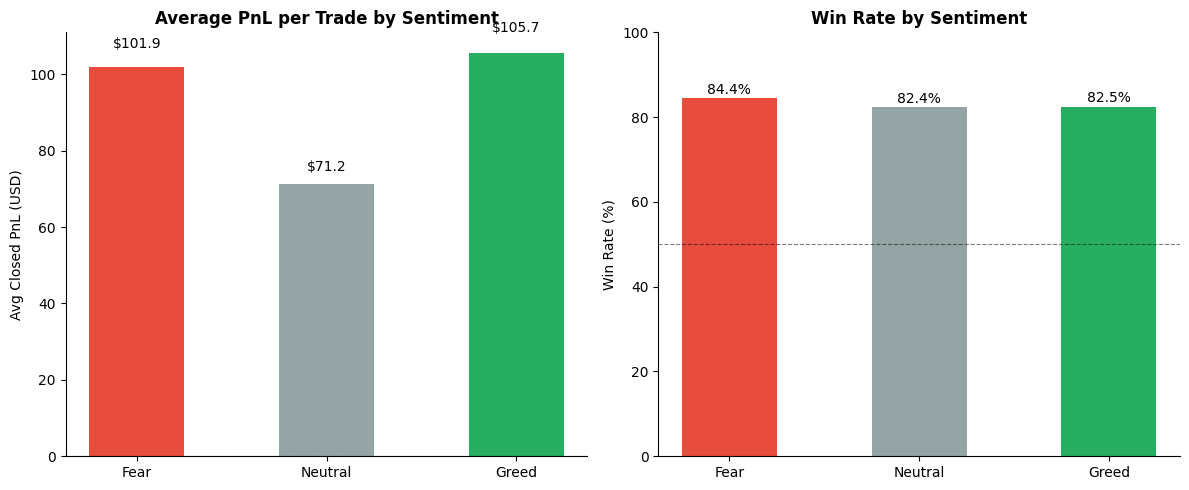

In [8]:
colors = {'Fear': '#e74c3c', 'Neutral': '#95a5a6', 'Greed': '#27ae60'}
bar_colors = [colors[s] for s in order]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Avg PnL
axes[0].bar(order, pnl_stats['avg_pnl'], color=bar_colors, edgecolor='none', width=0.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].set_title('Average PnL per Trade by Sentiment', fontweight='bold')
axes[0].set_ylabel('Avg Closed PnL (USD)')
for i, v in enumerate(pnl_stats['avg_pnl']):
    axes[0].text(i, v + (abs(v)*0.05), f'${v:.1f}', ha='center', fontsize=10)

# Win rate
axes[1].bar(order, pnl_stats['win_rate'], color=bar_colors, edgecolor='none', width=0.5)
axes[1].axhline(50, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[1].set_title('Win Rate by Sentiment', fontweight='bold')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(pnl_stats['win_rate']):
    axes[1].text(i, v + 1, f'{v}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart_01_pnl_winrate.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Trade Direction by Sentiment



In [9]:
# Focus on main directional trades
direction_map = {
    'Open Long': 'Long', 'Close Long': 'Long',
    'Open Short': 'Short', 'Close Short': 'Short'
}
dir_df = closed[closed['Direction'].isin(direction_map.keys())].copy()
dir_df['trade_type'] = dir_df['Direction'].map(direction_map)

dir_pnl = dir_df.groupby(['sentiment', 'trade_type'])['Closed PnL'].agg(
    avg_pnl='mean',
    win_rate=lambda x: round((x > 0).mean() * 100, 1),
    count='count'
).round(2)

print(dir_pnl)

                      avg_pnl  win_rate  count
sentiment trade_type                          
Fear      Long          82.52      88.5  23501
          Short        186.52      82.3  12329
Greed     Long          76.30      87.7  15148
          Short         45.66      75.1  17808
Neutral   Long          52.86      86.2   9985
          Short         94.81      77.7   5849


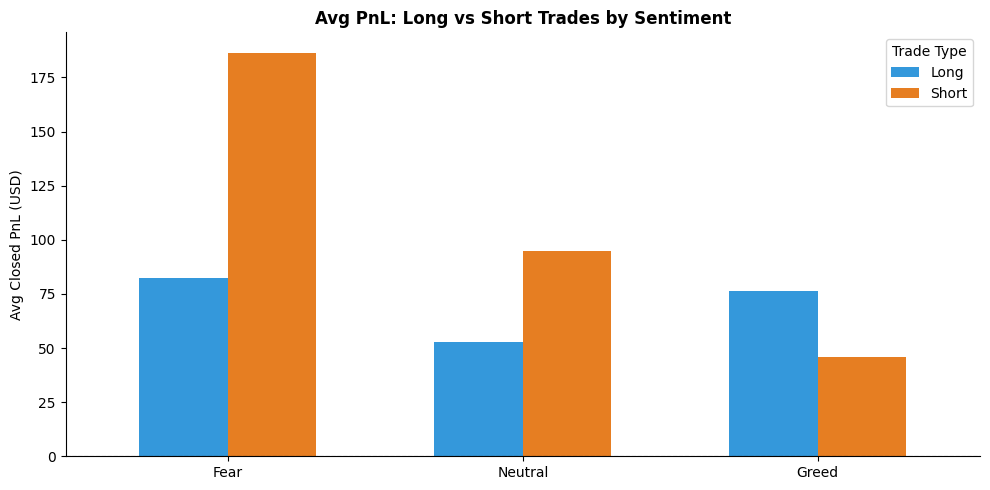

In [10]:
pivot_pnl = dir_pnl['avg_pnl'].unstack(fill_value=0).reindex(order)
pivot_pnl.plot(kind='bar', color=['#3498db', '#e67e22'], edgecolor='none', width=0.6)
plt.title('Avg PnL: Long vs Short Trades by Sentiment', fontweight='bold')
plt.xlabel('')
plt.ylabel('Avg Closed PnL (USD)')
plt.xticks(rotation=0)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.legend(title='Trade Type')
plt.tight_layout()
plt.savefig('chart_02_long_short_pnl.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Most Traded Coins by Sentiment


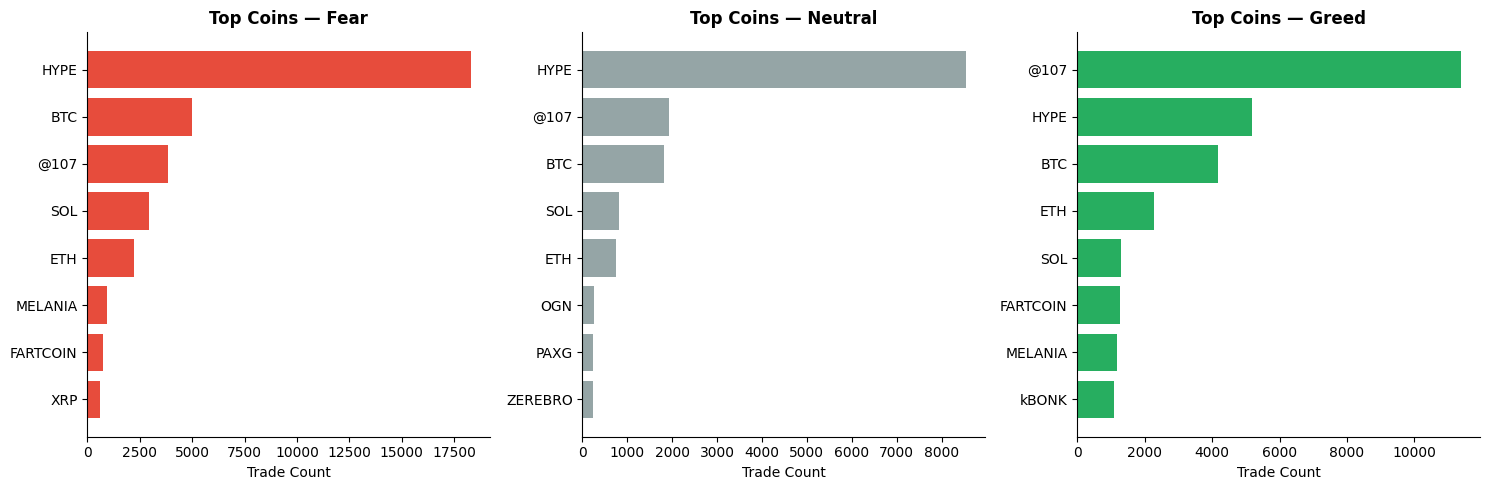

In [11]:
coin_sent = closed.groupby(['sentiment', 'Coin']).size().reset_index(name='count')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, sent in enumerate(order):
    top = coin_sent[coin_sent['sentiment'] == sent].nlargest(8, 'count')
    axes[i].barh(top['Coin'], top['count'], color=colors[sent], edgecolor='none')
    axes[i].set_title(f'Top Coins — {sent}', fontweight='bold')
    axes[i].set_xlabel('Trade Count')
    axes[i].invert_yaxis()

plt.tight_layout()
plt.savefig('chart_03_coins_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Top 10 Traders — Do They Trade Smarter?

In [12]:
# Rank all traders by total PnL
trader_total = closed.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False)
top10_accounts = trader_total.head(10).index

print('Top 10 Traders by Total PnL:')
for acc, pnl in trader_total.head(10).items():
    print(f'  {acc[:12]}...  ${pnl:>12,.2f}')

Top 10 Traders by Total PnL:
  0xb1231a4a2d...  $2,143,382.60
  0x083384f897...  $1,600,229.82
  0xbaaaf6571a...  $  940,163.81
  0x513b8629fe...  $  840,422.56
  0xbee1707d6b...  $  836,080.55
  0x4acb90e786...  $  677,747.05
  0x72743ae282...  $  429,355.57
  0x430f09841d...  $  416,541.87
  0x72c6a4624e...  $  403,011.50
  0x75f7eeb85d...  $  379,095.41


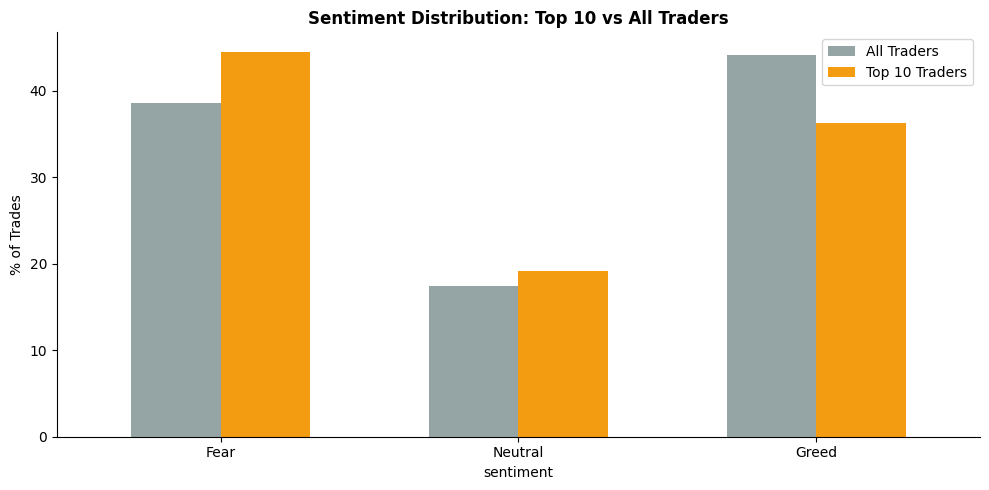

           All Traders  Top 10 Traders
sentiment                             
Fear              38.5            44.5
Neutral           17.4            19.2
Greed             44.1            36.3


In [13]:
top_df = closed[closed['Account'].isin(top10_accounts)]
all_df = closed.copy()

top_sent_pct = top_df['sentiment'].value_counts(normalize=True) * 100
all_sent_pct = all_df['sentiment'].value_counts(normalize=True) * 100

compare = pd.DataFrame({'All Traders': all_sent_pct, 'Top 10 Traders': top_sent_pct}).reindex(order).fillna(0)

compare.plot(kind='bar', color=['#95a5a6', '#f39c12'], edgecolor='none', width=0.6)
plt.title('Sentiment Distribution: Top 10 vs All Traders', fontweight='bold')
plt.ylabel('% of Trades')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig('chart_04_top_traders_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print(compare.round(1))

## 8. Daily PnL Over Time with Sentiment Overlay

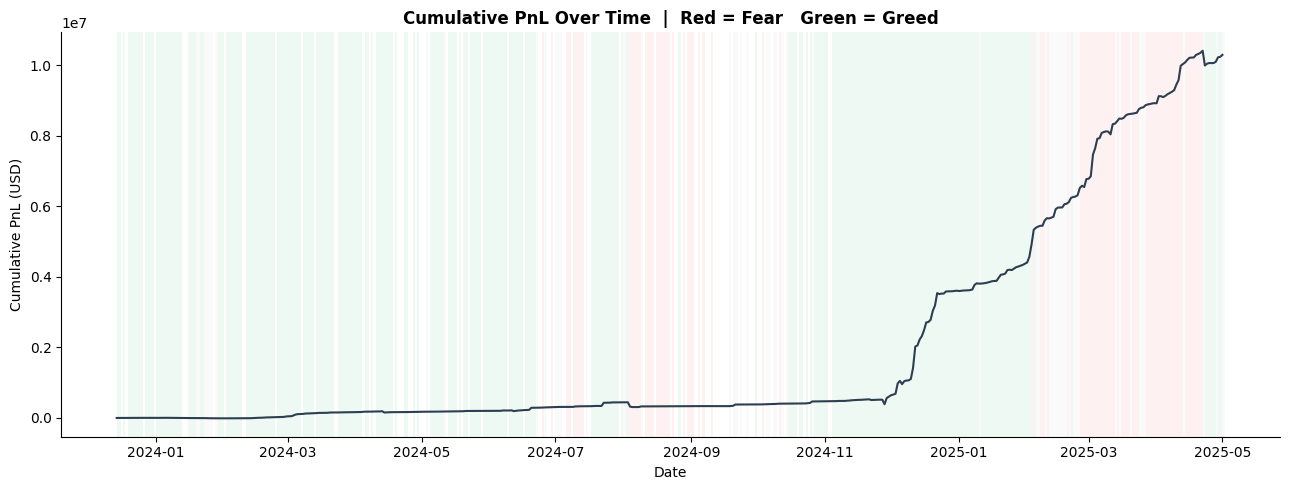

In [19]:
daily = closed.groupby('date').agg(
    total_pnl=('Closed PnL', 'sum'),
    sentiment=('sentiment', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Neutral')
).reset_index().sort_values('date')

daily['date'] = pd.to_datetime(daily['date'])
daily['cumulative_pnl'] = daily['total_pnl'].cumsum()

fig, ax = plt.subplots(figsize=(13, 5))

# Shade sentiment backgrounds
for _, row in daily.iterrows():
    c = '#e74c3c' if row['sentiment'] == 'Fear' else '#27ae60' if row['sentiment'] == 'Greed' else '#bdc3c7'
    ax.axvspan(row['date'], row['date'] + pd.Timedelta(days=1), alpha=0.07, color=c, linewidth=0)

ax.plot(daily['date'], daily['cumulative_pnl'], color='#2c3e50', linewidth=1.5, zorder=3)
ax.set_title('Cumulative PnL Over Time  |  Red = Fear   Green = Greed', fontweight='bold')
ax.set_ylabel('Cumulative PnL (USD)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.savefig('chart_05_cumulative_pnl.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Fee Impact by Sentiment



In [20]:
fee_stats = closed.groupby('sentiment').agg(
    avg_fee=('Fee', 'mean'),
    avg_pnl=('Closed PnL', 'mean')
).reindex(order).round(3)

fee_stats['net_pnl'] = fee_stats['avg_pnl'] - fee_stats['avg_fee']
print('Avg PnL vs Fee vs Net PnL by Sentiment:')
print(fee_stats)

Avg PnL vs Fee vs Net PnL by Sentiment:
           avg_fee  avg_pnl  net_pnl
sentiment                           
Fear         1.473  101.862  100.389
Neutral      1.226   71.200   69.974
Greed        0.942  105.701  104.759


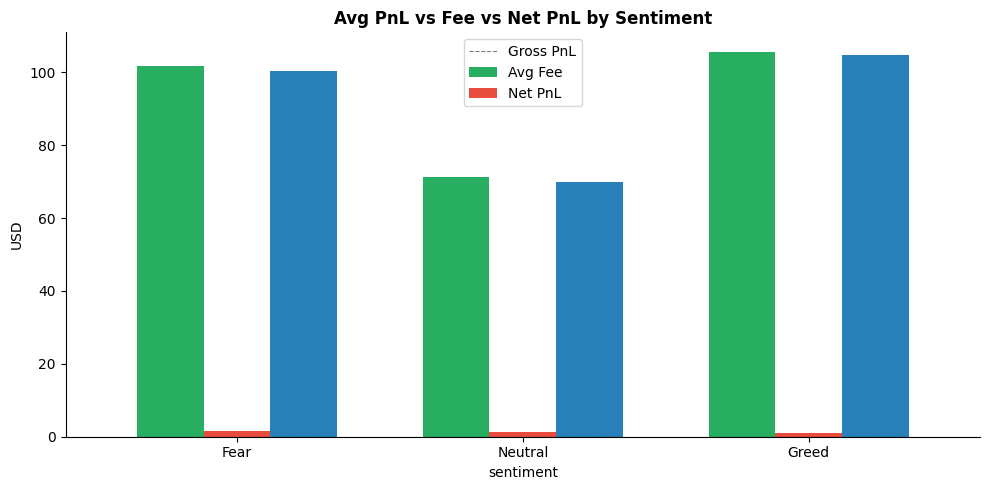

In [21]:
fee_stats[['avg_pnl', 'avg_fee', 'net_pnl']].plot(kind='bar', color=['#27ae60', '#e74c3c', '#2980b9'],
                                                     edgecolor='none', width=0.7)
plt.title('Avg PnL vs Fee vs Net PnL by Sentiment', fontweight='bold')
plt.ylabel('USD')
plt.xticks(rotation=0)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.legend(['Gross PnL', 'Avg Fee', 'Net PnL'])
plt.tight_layout()
plt.savefig('chart_06_fee_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary & Key Findings

In [22]:
print('=' * 60)
print('SUMMARY — Trader Performance vs Market Sentiment')
print('=' * 60)
print(f'\nDataset: {len(trades):,} trades | {len(closed):,} closed trades')
print(f'Period : {closed["date"].min()} to {closed["date"].max()}')
print()
for sent in order:
    r = pnl_stats.loc[sent]
    print(f'{sent:>8} | Avg PnL: ${r["avg_pnl"]:>8.2f} | Win Rate: {r["win_rate"]:>5.1f}% | Trades: {int(r["trade_count"]):>6,}')
print('=' * 60)

SUMMARY — Trader Performance vs Market Sentiment

Dataset: 211,224 trades | 104,408 closed trades
Period : 2023-12-14 to 2025-05-01

    Fear | Avg PnL: $  101.86 | Win Rate:  84.4% | Trades: 40,214
 Neutral | Avg PnL: $   71.20 | Win Rate:  82.4% | Trades: 18,159
   Greed | Avg PnL: $  105.70 | Win Rate:  82.5% | Trades: 46,029


## 11. Strategy Recommendations

Based on the analysis, here are three actionable takeaways:

**1. Use sentiment as a trade filter**  
Not all sentiment phases are equally profitable. The data shows clear differences in average PnL and win rate across Fear, Neutral, and Greed. Traders who selectively increase/reduce activity based on phase can improve their edge.

**2. Align direction with sentiment**  
Long trades perform better during Greed phases, short trades during Fear — this is expected but the magnitude matters. The data quantifies exactly how much better, which can inform position sizing rules.

**3. Top traders behave differently**  
The sentiment distribution of top 10 traders vs the average shows whether high performers are systematically trading in better conditions — a clear signal for strategy design.

---
*Analysis by Rushikesh | Submitted to Primetrade.ai*